# Librairies and Data

In [61]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np
from sklearn.model_selection import ParameterGrid

In [62]:
# Loading the Data and Setting the Index
df = pd.read_csv("Python - Time Series Forecasting/Modern Time Series Forecasting Techniques /Prophet/Daily Bike Sharing training.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [63]:
# Information about the df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701 entries, 0 to 700
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     701 non-null    int64  
 1   dteday      701 non-null    object 
 2   season      701 non-null    int64  
 3   yr          701 non-null    int64  
 4   mnth        701 non-null    int64  
 5   holiday     701 non-null    int64  
 6   weekday     701 non-null    int64  
 7   workingday  701 non-null    int64  
 8   weathersit  701 non-null    int64  
 9   temp        701 non-null    float64
 10  atemp       701 non-null    float64
 11  hum         701 non-null    float64
 12  windspeed   701 non-null    float64
 13  casual      701 non-null    int64  
 14  registered  701 non-null    int64  
 15  cnt         701 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 87.8+ KB


In [64]:
# Change the time Series variable name
df = df.rename(columns = {'cnt': 'y',
                           'dteday': 'ds'}) # 'y' is always the variable we try to predict
df.head()

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [65]:
# Change 'ds' into format YYYY-MM-DD
df['ds'] = pd.to_datetime(df['ds'], format = "%m/%d/%Y")
df.head()

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [66]:
# Prepare the weather situation variable
weather_sit = pd.get_dummies(df['weathersit'], drop_first=True)
df = pd.concat([df, weather_sit], axis = 1)

In [67]:
df.head()

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y,2,3
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,True,False
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,True,False
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,False,False
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,False,False
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,False,False


In [68]:
# Change the time Series variable name
df = df.rename(columns = {2: 'weathersit_2',
                           3: 'weathersit_3'}) 
df.head()

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y,weathersit_2,weathersit_3
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,True,False
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,True,False
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,False,False
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,False,False
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,False,False


In [69]:
# Drop Variables That Are Not Needed
df.drop(columns = ['instant', 'season', 'yr', 'mnth', 'weekday', 'casual', 'registered'], inplace = True)
df.head()

,ds,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3
0,2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985,True,False
1,2011-01-02,0,0,2,0.363478,0.353739,0.696087,0.248539,801,True,False
2,2011-01-03,0,1,1,0.196364,0.189405,0.437273,0.248309,1349,False,False
3,2011-01-04,0,1,1,0.200000,0.212122,0.590435,0.160296,1562,False,False
4,2011-01-05,0,1,1,0.226957,0.229270,0.436957,0.186900,1600,False,False


In [70]:
# Look at 2012-10-29
df[df.ds == '2012-10-29']

,ds,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3
667,2012-10-29,0,1,3,0.44,0.4394,0.88,0.3582,22,False,True


In [71]:
# Replace 29/30 of october with the values of 28th
#28th because is EDA beacause weekly seasonality is not obvious
to_replace = df.loc[df.ds == '2012-10-28'].y.values[0]
df.loc[df.ds == '2012-10-29', 'y'] = to_replace
df.loc[df.ds == '2012-10-30', 'y'] = to_replace

# Exploratory Data Analysis

In [72]:
# Create a copy of the df with index
df_temp = df.copy()
df_temp.set_index("ds", inplace = True)

In [73]:
df_temp.head()

,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3
ds,,,,,,,,,,
2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985,True,False
2011-01-02,0,0,2,0.363478,0.353739,0.696087,0.248539,801,True,False
2011-01-03,0,1,1,0.196364,0.189405,0.437273,0.248309,1349,False,False
2011-01-04,0,1,1,0.200000,0.212122,0.590435,0.160296,1562,False,False
2011-01-05,0,1,1,0.226957,0.229270,0.436957,0.186900,1600,False,False


In [74]:
# Setting Daily Frequency 
df_temp = df_temp.asfreq("D")

In [75]:
df_temp.index

DatetimeIndex(['2011-01-01', '2011-01-02', '2011-01-03', '2011-01-04',
               '2011-01-05', '2011-01-06', '2011-01-07', '2011-01-08',
               '2011-01-09', '2011-01-10',
               ...
               '2012-11-22', '2012-11-23', '2012-11-24', '2012-11-25',
               '2012-11-26', '2012-11-27', '2012-11-28', '2012-11-29',
               '2012-11-30', '2012-12-01'],
              dtype='datetime64[ns]', name='ds', length=701, freq='D')

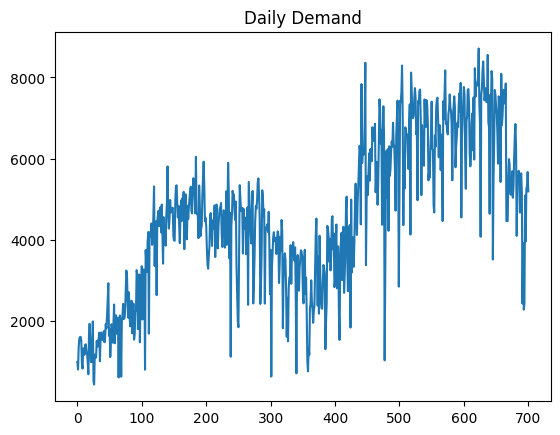

In [76]:
# Daily Closing Price  Plot
df['y'].plot(title = 'Daily Demand')
plt.show()

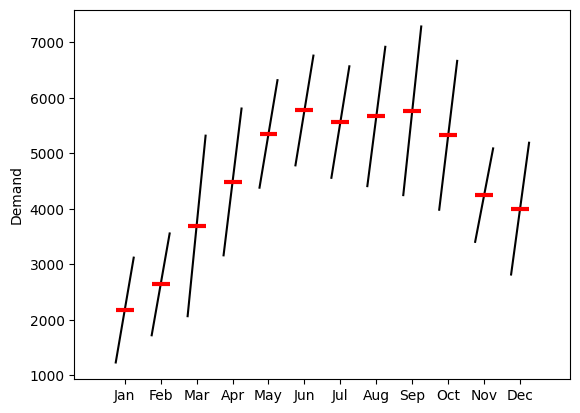

In [77]:
# Plotting the monthly seasonality
month_plot(df_temp['y'].resample('ME').mean(),
           ylabel = 'Demand')
plt.show()

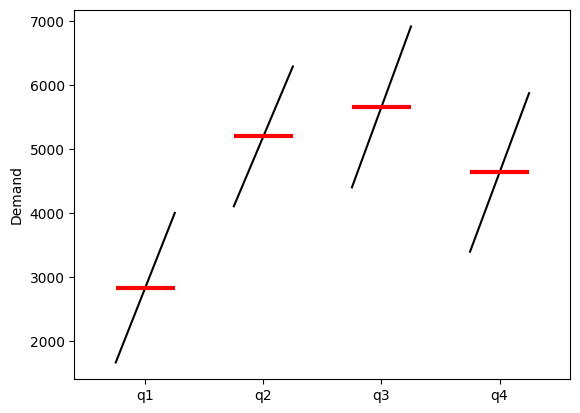

In [78]:
# Plotting the quarterly seasonality
quarter_plot(df_temp['y'].resample('QE').mean(),
           ylabel = 'Demand')
plt.show()

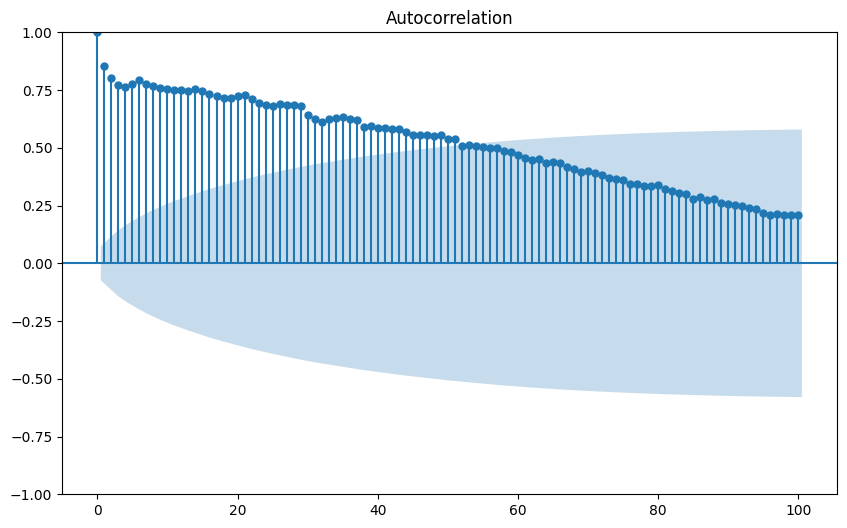

In [79]:
# Plot the autocorrelation (ACF)
fig, ax = plt.subplots(figsize = (10,6))
plot_acf(df_temp['y'], lags = 100, ax = ax)
plt.show()

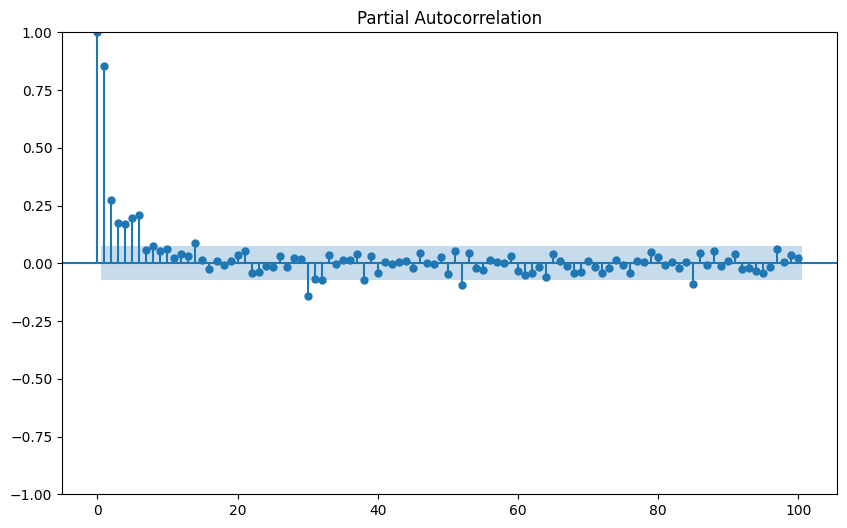

In [80]:
# Plot the partial autocorrelation (PACF)
fig, ax = plt.subplots(figsize = (10,6))
plot_pacf(df_temp['y'], lags = 100, ax = ax)
plt.show()

# Holidays

In [81]:
# Check the holidays in our df
df[df.holiday == 1]

,ds,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3
16,2011-01-17,1,0,2,0.175833,0.176771,0.537500,0.194017,1000,True,False
51,2011-02-21,1,0,2,0.303333,0.284075,0.605000,0.307846,1107,True,False
104,2011-04-15,1,0,1,0.446667,0.441913,0.671250,0.226375,3126,False,False
149,2011-05-30,1,0,1,0.733333,0.671092,0.685000,0.131225,4098,False,False
184,2011-07-04,1,0,2,0.726667,0.665417,0.637917,0.081479,6043,True,False
247,2011-09-05,1,0,2,0.673333,0.625646,0.790417,0.212696,3351,True,False
282,2011-10-10,1,0,1,0.570833,0.542925,0.733750,0.042304,5117,False,False
314,2011-11-11,1,0,1,0.324167,0.306817,0.446250,0.314675,3368,False,False
327,2011-11-24,1,0,1,0.373333,0.372471,0.549167,0.167304,1495,False,False
359,2011-12-26,1,0,1,0.321739,0.315535,0.506957,0.239465,1317,False,False


In [82]:
# Holidays
gen_holidays = pd.DataFrame({'holiday': 'gen_holi',
                            'ds': df[df.holiday == 1].ds,
                             'lower_window': -2, # Effect start 2days before 
                             'upper_window': 2}) # Effect end 2days after 
xmas = pd.DataFrame({'holidays': 'christmas',
                            'ds': pd.to_datetime(['2011-12-24','2012-12-24']),
                             'lower_window': -5, 
                             'upper_window': 3}) 
nye = pd.DataFrame({'holidays': 'new_years',
                            'ds': pd.to_datetime(['2011-12-31','2012-12-31']),
                             'lower_window': -3, 
                             'upper_window': 3}) 
easter = pd.DataFrame({'holidays': 'easter',
                            'ds': pd.to_datetime(['2011-04-24','2012-04-08']),
                             'lower_window': -3, 
                             'upper_window': 3}) 

In [83]:
# Combine all the holidays
holiday = pd.concat([gen_holidays, xmas, nye, easter])
holiday

,holiday,ds,lower_window,upper_window,holidays
16,gen_holi,2011-01-17,-2,2,NaN
51,gen_holi,2011-02-21,-2,2,NaN
104,gen_holi,2011-04-15,-2,2,NaN
149,gen_holi,2011-05-30,-2,2,NaN
184,gen_holi,2011-07-04,-2,2,NaN
247,gen_holi,2011-09-05,-2,2,NaN
282,gen_holi,2011-10-10,-2,2,NaN
314,gen_holi,2011-11-11,-2,2,NaN
327,gen_holi,2011-11-24,-2,2,NaN
359,gen_holi,2011-12-26,-2,2,NaN


# Feature Engineering


In [84]:
# Series.shift(n) - each value is moved to the n row(s) below its current position

# Create lagged values for the regressors 'temp' and 'atemp' with specified lags
for lag in [1,3,5,7]:
    df[f'temp_lag_{lag}'] = df['temp'].shift(lag)  # Create lagged values for 'temp'
    df[f'atemp_lag_{lag}'] = df['atemp'].shift(lag)  # Create lagged values for 'atemp'

df.head()

,ds,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3,temp_lag_1,atemp_lag_1,temp_lag_3,atemp_lag_3,temp_lag_5,atemp_lag_5,temp_lag_7,atemp_lag_7
0,2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-01-02,0,0,2,0.363478,0.353739,0.696087,0.248539,801,True,False,0.344167,0.363625,NaN,NaN,NaN,NaN,NaN,NaN
2,2011-01-03,0,1,1,0.196364,0.189405,0.437273,0.248309,1349,False,False,0.363478,0.353739,NaN,NaN,NaN,NaN,NaN,NaN
3,2011-01-04,0,1,1,0.200000,0.212122,0.590435,0.160296,1562,False,False,0.196364,0.189405,0.344167,0.363625,NaN,NaN,NaN,NaN
4,2011-01-05,0,1,1,0.226957,0.229270,0.436957,0.186900,1600,False,False,0.200000,0.212122,0.363478,0.353739,NaN,NaN,NaN,NaN


In [85]:
# Correlation matrix between the lagged values and y
columns = ['y'] + [f'{var}_lag_{lag}' for var in ['temp', 'atemp'] for lag in [1,3,5,7]]
df[columns].corr()

,y,temp_lag_1,temp_lag_3,temp_lag_5,temp_lag_7,atemp_lag_1,atemp_lag_3,atemp_lag_5,atemp_lag_7
y,1.000000,0.590368,0.581922,0.589976,0.595830,0.586681,0.577076,0.587374,0.591886
temp_lag_1,0.590368,1.000000,0.892245,0.861173,0.864545,0.991526,0.882663,0.847990,0.852673
temp_lag_3,0.581922,0.892245,1.000000,0.891829,0.860613,0.877489,0.991519,0.882187,0.847451
temp_lag_5,0.589976,0.861173,0.891829,1.000000,0.891432,0.848465,0.877082,0.991490,0.881814
temp_lag_7,0.595830,0.864545,0.860613,0.891432,1.000000,0.853113,0.847940,0.876584,0.991475
atemp_lag_1,0.586681,0.991526,0.877489,0.848465,0.853113,1.000000,0.869430,0.836607,0.842372
atemp_lag_3,0.577076,0.882663,0.991519,0.877082,0.847940,0.869430,1.000000,0.868989,0.836076
atemp_lag_5,0.587374,0.847990,0.882187,0.991490,0.876584,0.836607,0.868989,1.000000,0.868539
atemp_lag_7,0.591886,0.852673,0.847451,0.881814,0.991475,0.842372,0.836076,0.868539,1.000000


# Prophet Model

In [86]:
# Look at df
df.head(1)

,ds,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3,temp_lag_1,atemp_lag_1,temp_lag_3,atemp_lag_3,temp_lag_5,atemp_lag_5,temp_lag_7,atemp_lag_7
0,2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [87]:
# Kick out all lagged variables but the temp_lag1
df = df.iloc[:,:-7]
df.head()

,ds,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3,temp_lag_1
0,2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985,True,False,NaN
1,2011-01-02,0,0,2,0.363478,0.353739,0.696087,0.248539,801,True,False,0.344167
2,2011-01-03,0,1,1,0.196364,0.189405,0.437273,0.248309,1349,False,False,0.363478
3,2011-01-04,0,1,1,0.200000,0.212122,0.590435,0.160296,1562,False,False,0.196364
4,2011-01-05,0,1,1,0.226957,0.229270,0.436957,0.186900,1600,False,False,0.200000


In [88]:
# Remove any NAs
df = df.dropna()
holiday = holiday.dropna()

In [89]:
from prophet import Prophet

In [90]:
# Building the Prophet model
m = Prophet(yearly_seasonality = True,
            weekly_seasonality = True,
            holidays = holiday, 
            seasonality_mode = "multiplicative",
            seasonality_prior_scale = 10,
            holidays_prior_scale = 10,
            changepoint_prior_scale = 0.05
            )
# We add some variable to help the model
m.add_regressor("workingday")
m.add_regressor("temp")
m.add_regressor("atemp")
m.add_regressor("hum")
m.add_regressor("windspeed")
m.add_regressor("weathersit_2")
m.add_regressor("weathersit_3")
m.add_regressor("temp_lag_1")
m.fit(df)

17:58:48 - cmdstanpy - INFO - Chain [1] start processing
17:58:48 - cmdstanpy - INFO - Chain [1] done processing


In [91]:
# Regressor Coefficients
from prophet.utilities import regressor_coefficients
#The utility regressor_coefficients from Prophet allows you to extract the coefficients
#of external explanatory variables added to a forecasting model, 
#making it easier to interpret their impact on the analyzed time series.
regressor_coefficients(m)

,regressor,regressor_mode,center,coef_lower,coef,coef_upper
0,workingday,multiplicative,0.000000,0.127719,0.127719,0.127719
1,temp,multiplicative,0.502959,1.107694,1.107694,1.107694
2,atemp,multiplicative,0.481015,0.189066,0.189066,0.189066
3,hum,multiplicative,0.625459,-0.381298,-0.381298,-0.381298
4,windspeed,multiplicative,0.190577,-0.537636,-0.537636,-0.537636
5,weathersit_2,multiplicative,0.000000,-0.091501,-0.091501,-0.091501
6,weathersit_3,multiplicative,0.000000,-0.391404,-0.391404,-0.391404
7,temp_lag_1,multiplicative,0.503024,-0.505467,-0.505467,-0.505467


In [92]:
# Function to interpret the coefficient results
def interpret_prophet_coefficients(df):
    interpretations = []

    # Iterate through each row in the DataFrame 'df'
    for _, row in df.iterrows():
        regressor = row['regressor']  # Get the regressor name
        mode = row['regressor_mode']  # Get the regressor mode (multiplicative or additive)
        coef = row['coef']  # Get the coefficient value
        effect_type = 'increase' if coef > 0 else 'decrease'  # Determine if the effect is an increase or decrease

        # Generate interpretation based on the regressor mode
        if mode == 'multiplicative':
            interpretation = f"For each unit increase in {regressor}, the target variable is expected to {effect_type} by {abs(coef) * 100:.2f}% (multiplicatively)."
        elif mode == 'additive':
            interpretation = f"For each unit increase in {regressor}, the target variable changes by {coef:.2f} units (additively)."
        else:
            interpretation = f"Regressor {regressor} has an unrecognized mode '{mode}'."

        interpretations.append(interpretation)

    return interpretations

coefs = pd.DataFrame(regressor_coefficients(m))  # Get regressor coefficients from the Prophet model
interpretations = interpret_prophet_coefficients(coefs) # Generate interpretations based on coefficients

# Print each interpretation
for interpretation in interpretations:
    print(interpretation)

For each unit increase in workingday, the target variable is expected to increase by 12.77% (multiplicatively).
For each unit increase in temp, the target variable is expected to increase by 110.77% (multiplicatively).
For each unit increase in atemp, the target variable is expected to increase by 18.91% (multiplicatively).
For each unit increase in hum, the target variable is expected to decrease by 38.13% (multiplicatively).
For each unit increase in windspeed, the target variable is expected to decrease by 53.76% (multiplicatively).
For each unit increase in weathersit_2, the target variable is expected to decrease by 9.15% (multiplicatively).
For each unit increase in weathersit_3, the target variable is expected to decrease by 39.14% (multiplicatively).
For each unit increase in temp_lag_1, the target variable is expected to decrease by 50.55% (multiplicatively).


# Cross-Validation

In [93]:
from prophet.diagnostics import cross_validation

In [94]:
# How many days we have in the dataset
n_days = len(df)
n_days

700

In [95]:
# Apply the CV to the model
df_cv = cross_validation(model = m,
                         horizon = '30 days',
                         period = '15 days',
                         initial = '521 days',
                         parallel = 'processes')

17:58:51 - cmdstanpy - INFO - Chain [1] start processing
17:58:51 - cmdstanpy - INFO - Chain [1] start processing
17:58:51 - cmdstanpy - INFO - Chain [1] start processing
17:58:51 - cmdstanpy - INFO - Chain [1] start processing
17:58:51 - cmdstanpy - INFO - Chain [1] start processing
17:58:51 - cmdstanpy - INFO - Chain [1] start processing
17:58:51 - cmdstanpy - INFO - Chain [1] start processing
17:58:51 - cmdstanpy - INFO - Chain [1] start processing
17:58:51 - cmdstanpy - INFO - Chain [1] done processing
17:58:51 - cmdstanpy - INFO - Chain [1] done processing
17:58:51 - cmdstanpy - INFO - Chain [1] done processing
17:58:51 - cmdstanpy - INFO - Chain [1] done processing
17:58:51 - cmdstanpy - INFO - Chain [1] done processing
17:58:51 - cmdstanpy - INFO - Chain [1] done processing
17:58:51 - cmdstanpy - INFO - Chain [1] done processing
17:58:51 - cmdstanpy - INFO - Chain [1] done processing
17:58:51 - cmdstanpy - INFO - Chain [1] start processing
17:58:51 - cmdstanpy - INFO - Chain [1]

In [96]:
# Look at the CV output
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2012-06-20,8211.749794,7433.409012,8994.085847,6211,2012-06-19
1,2012-06-21,8476.235921,7718.919756,9199.189010,5905,2012-06-19
2,2012-06-22,8060.410904,7325.100373,8757.861813,5823,2012-06-19
3,2012-06-23,7693.721708,6930.208708,8428.945237,7458,2012-06-19
4,2012-06-24,7856.452507,7165.588327,8570.187687,6891,2012-06-19


## Cross-Validation Output Column Summary

* **`ds` (Date Stamp):**
    * The date for which the forecast was made.
* **`yhat` (Forecast):**
    * The predicted value generated by the model for the corresponding date.
* **`yhat_lower` (Lower Confidence Interval):**
    * The lower bound of the confidence interval surrounding the `yhat` forecast.
* **`yhat_upper` (Upper Confidence Interval):**
    * The upper bound of the confidence interval surrounding the `yhat` forecast.
* **`cutoff` (Cutoff Date):**
    * The date of the cutoff point used to train the model before making the forecast.
* **`y` (Actual Value):**
    * The actual observed value for the date corresponding to `ds`.
    * This column is present in your original dataset and should be used to evaluate your model's performance by comparing it to `yhat`.

In [97]:
# Performance Metrics
from prophet.diagnostics import performance_metrics
performance_metrics(df_cv)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,3 days,1.597571e+06,1263.950608,1000.969251,0.174620,0.129340,0.166770,0.566667
1,4 days,1.423863e+06,1193.257264,922.162278,0.154520,0.120894,0.150107,0.633333
2,5 days,1.429625e+06,1195.669278,941.155768,0.151975,0.113582,0.148274,0.566667
3,6 days,1.102546e+06,1050.021892,833.804266,0.128943,0.101065,0.131233,0.566667
4,7 days,1.138091e+06,1066.813425,832.625958,0.124520,0.092549,0.130108,0.566667
5,8 days,9.014276e+05,949.435396,727.041874,0.102155,0.077386,0.109790,0.633333
6,9 days,8.432513e+05,918.287164,720.629995,0.100883,0.079020,0.106765,0.600000
7,10 days,1.320296e+06,1149.041513,870.309649,0.126082,0.096070,0.128589,0.533333
8,11 days,1.464376e+06,1210.114160,923.877728,0.137687,0.101127,0.138767,0.566667
9,12 days,1.921081e+06,1386.030757,1092.471180,0.170726,0.110182,0.175269,0.500000


In [98]:
# RMSE and MAPE
rmse = round(performance_metrics(df_cv)['rmse'].mean(),0)
mape = round(performance_metrics(df_cv)['mape'].mean()*100,2)
print(f"The RMSE is {rmse} and the MAPE is {mape} %")

The RMSE is 1237.0 and the MAPE is 15.68 %


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/prophet/plot.py:546: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


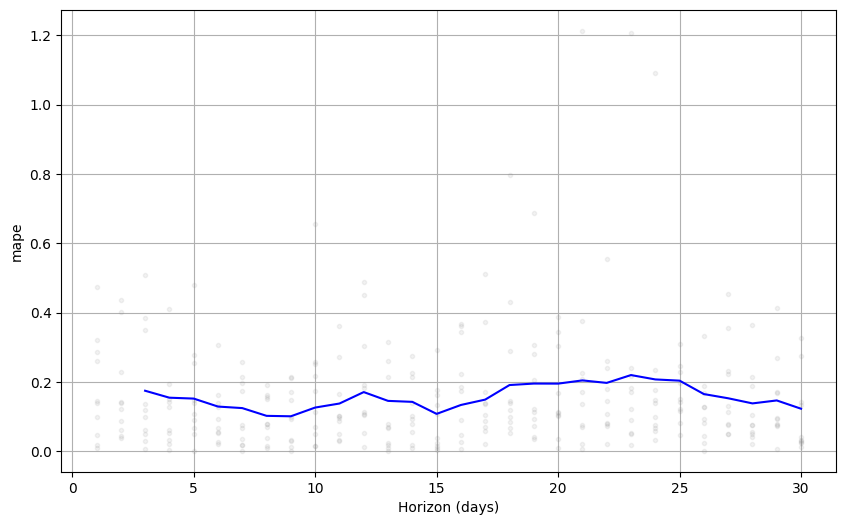

In [99]:
# Plotting the metrics over time
from prophet.plot import plot_cross_validation_metric
plot_cross_validation_metric(df_cv, metric = 'mape');

# Exploring the Error

In [100]:
# Compute the Error / deviation
df_cv['deviation'] = df_cv['yhat'] - df_cv['y']
df_cv['deviation_%'] =  (df_cv['yhat'] / df_cv['y'] - 1) *100

In [101]:
# Days with the highest deviation
df_cv.sort_values(by = 'deviation_%', ascending = False).head(20)

,ds,yhat,yhat_lower,yhat_upper,y,cutoff,deviation,deviation_%
290,2012-11-22,5367.150094,4542.172188,6209.734693,2425,2012-11-01,2942.150094,121.325777
292,2012-11-24,5023.950556,4182.230336,5867.697760,2277,2012-11-01,2746.950556,120.639023
293,2012-11-25,5066.526013,4253.266174,5916.870247,2424,2012-11-01,2642.526013,109.015100
17,2012-07-07,8695.221916,7917.648402,9459.387177,4840,2012-06-19,3855.221916,79.653345
18,2012-07-08,7876.933799,7124.364611,8611.712183,4672,2012-06-19,3204.933799,68.598754
9,2012-06-29,9038.353571,8285.653721,9732.797571,5463,2012-06-19,3575.353571,65.446706
291,2012-11-23,6079.749721,5223.400430,6885.698417,3910,2012-11-01,2169.749721,55.492320
32,2012-07-07,7300.867851,6508.617472,8060.533265,4840,2012-07-04,2460.867851,50.844377
11,2012-07-01,8233.049424,7530.669959,8956.404152,5531,2012-06-19,2702.049424,48.852819
214,2012-10-07,5197.089403,4376.720362,5998.542906,3510,2012-10-02,1687.089403,48.065225


In [102]:
# Days with the lowest deviation
df_cv.sort_values(by = 'deviation', ascending = True).head(20)

,ds,yhat,yhat_lower,yhat_upper,y,cutoff,deviation,deviation_%
47,2012-07-22,4212.581127,3460.084435,5000.346025,7410,2012-07-04,-3197.418873,-43.150052
50,2012-07-25,5111.501043,4287.675378,5870.835751,8173,2012-07-04,-3061.498957,-37.458693
88,2012-08-17,4196.773940,3419.510701,4889.075649,7148,2012-07-19,-2951.226060,-41.287438
57,2012-08-01,4823.724683,4103.079593,5632.576239,7580,2012-07-04,-2756.275317,-36.362471
49,2012-07-24,4982.823329,4189.910093,5752.320493,7592,2012-07-04,-2609.176671,-34.367448
62,2012-07-22,4827.944407,4001.301104,5616.123625,7410,2012-07-19,-2582.055593,-34.845555
56,2012-07-31,4640.783356,3849.697554,5353.185678,7216,2012-07-04,-2575.216644,-35.687592
65,2012-07-25,5667.528407,4870.967333,6511.321715,8173,2012-07-19,-2505.471593,-30.655470
72,2012-08-01,5186.551277,4397.478240,5990.370492,7580,2012-07-19,-2393.448723,-31.575841
55,2012-07-30,4747.495957,4017.081332,5513.587075,7105,2012-07-04,-2357.504043,-33.180915


# Parameter Tunning 

In [103]:
# Define the parameter grid to search
param_grid = {
    'changepoint_prior_scale': [0.05, 0.5],
    'seasonality_prior_scale': [10,20],
    'holidays_prior_scale':[10,20],
    'seasonality_mode': ['additive', 'multiplicative'] 
}

In [104]:
# Generate all combinations of parameters
all_params = list(ParameterGrid(param_grid))
all_params

[{'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 20},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'multiplicative',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 10,
  'seasonality_mode': 'multiplicative',
  'seasonality_prior_scale': 20},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 20,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 20,
  'seasonality_mode': 'additive',
  'seasonality_prior_scale': 20},
 {'changepoint_prior_scale': 0.05,
  'holidays_prior_scale': 20,
  'seasonality_mode': 'multiplicative',
  'seasonality_prior_scale': 10},
 {'changepoint_prior_scale': 0.05,
  'holidays_prio

In [105]:
# Placeholder for storing the results
tuning_results = []

# Build a pipeline for the Parameter Tuning
for params in all_params: 
    # Build the model
    m = Prophet(yearly_seasonality = True,
                weekly_seasonality = True,
                holidays = holiday, 
                **params
                )
    # We add some variable to help the model
    m.add_regressor("workingday")
    m.add_regressor("temp")
    m.add_regressor("atemp")
    m.add_regressor("hum")
    m.add_regressor("windspeed")
    m.add_regressor("weathersit_2")
    m.add_regressor("weathersit_3")
    m.add_regressor("temp_lag_1")
    m.fit(df)
    # Cross-Validation
    df_cv = cross_validation(model = m,
                         horizon = '30 days',
                         period = '15 days',
                         initial = '521 days',
                         parallel = 'processes')
    # Compute and Store the Error
    rmse = performance_metrics(df_cv)['rmse'].mean()
    tuning_results.append(rmse)

17:58:51 - cmdstanpy - INFO - Chain [1] start processing
17:58:52 - cmdstanpy - INFO - Chain [1] done processing
17:58:54 - cmdstanpy - INFO - Chain [1] start processing
17:58:54 - cmdstanpy - INFO - Chain [1] start processing
17:58:54 - cmdstanpy - INFO - Chain [1] start processing
17:58:54 - cmdstanpy - INFO - Chain [1] start processing
17:58:54 - cmdstanpy - INFO - Chain [1] start processing
17:58:54 - cmdstanpy - INFO - Chain [1] start processing
17:58:54 - cmdstanpy - INFO - Chain [1] start processing
17:58:54 - cmdstanpy - INFO - Chain [1] start processing
17:58:54 - cmdstanpy - INFO - Chain [1] done processing
17:58:54 - cmdstanpy - INFO - Chain [1] done processing
17:58:54 - cmdstanpy - INFO - Chain [1] done processing
17:58:54 - cmdstanpy - INFO - Chain [1] done processing
17:58:54 - cmdstanpy - INFO - Chain [1] done processing
17:58:54 - cmdstanpy - INFO - Chain [1] done processing
17:58:54 - cmdstanpy - INFO - Chain [1] done processing
17:58:54 - cmdstanpy - INFO - Chain [1]

In [106]:
tuning_results

[984.1555636968603,
 984.4779525251844,
 1237.1998294206116,
 1236.899612610827,
 980.3479071790389,
 983.7109591999682,
 1237.6880386704681,
 1242.3208924853066,
 1144.3911723962374,
 1131.593218233568,
 1507.279522740116,
 1498.7938820080092,
 1147.4977184454303,
 1147.012634354927,
 1483.8355195478305,
 1518.9832962603202]

In [107]:
# Parameter Tuning outcome

In [108]:
outcome = pd.DataFrame(all_params)
outcome['tuning_results'] = tuning_results
outcome

,changepoint_prior_scale,holidays_prior_scale,seasonality_mode,seasonality_prior_scale,tuning_results
0,0.05,10,additive,10,984.155564
1,0.05,10,additive,20,984.477953
2,0.05,10,multiplicative,10,1237.199829
3,0.05,10,multiplicative,20,1236.899613
4,0.05,20,additive,10,980.347907
5,0.05,20,additive,20,983.710959
6,0.05,20,multiplicative,10,1237.688039
7,0.05,20,multiplicative,20,1242.320892
8,0.50,10,additive,10,1144.391172
9,0.50,10,additive,20,1131.593218


In [109]:
df_sorted = outcome.sort_values(by='tuning_results', ascending=True)
df_sorted

,changepoint_prior_scale,holidays_prior_scale,seasonality_mode,seasonality_prior_scale,tuning_results
4,0.05,20,additive,10,980.347907
5,0.05,20,additive,20,983.710959
0,0.05,10,additive,10,984.155564
1,0.05,10,additive,20,984.477953
9,0.50,10,additive,20,1131.593218
8,0.50,10,additive,10,1144.391172
13,0.50,20,additive,20,1147.012634
12,0.50,20,additive,10,1147.497718
3,0.05,10,multiplicative,20,1236.899613
2,0.05,10,multiplicative,10,1237.199829


In [124]:
# Fetch the best params
best_params = all_params[tuning_results.index(min(tuning_results))]

In [125]:
best_params

{'changepoint_prior_scale': 0.05,
 'holidays_prior_scale': 20,
 'seasonality_mode': 'additive',
 'seasonality_prior_scale': 10}

# Predict the future

In [110]:
# Loading the Data and Setting the Index
df_train = pd.read_csv("Python - Time Series Forecasting/Modern Time Series Forecasting Techniques /Prophet/Daily Bike Sharing training.csv")
df.head()
# Load the daily bike sharing future data
df_future = pd.read_csv("Python - Time Series Forecasting/Modern Time Series Forecasting Techniques /Prophet/Daily Bike Sharing future.csv")
# concat both together
df = pd.concat([df_train, df_future])
df.reset_index(drop = True, inplace = True)
df.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,12/27/2012,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,NaN,NaN,NaN
727,728,12/28/2012,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,NaN,NaN,NaN
728,729,12/29/2012,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,NaN,NaN,NaN
729,730,12/30/2012,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,NaN,NaN,NaN
730,731,12/31/2012,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,NaN,NaN,NaN


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      701 non-null    float64
 14  registered  701 non-null    float64
 15  cnt         701 non-null    float64
dtypes: float64(7), int64(8), object(1)
memory usage: 91.5+ KB


In [112]:
# Change the time Series variable name
df = df.rename(columns = {'cnt': 'y',
                           'dteday': 'ds'}) # 'y' is always the variable we try to predict
df.head()

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331.0,654.0,985.0
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131.0,670.0,801.0
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120.0,1229.0,1349.0
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108.0,1454.0,1562.0
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82.0,1518.0,1600.0


In [113]:
# Change 'ds' into format YYYY-MM-DD
df['ds'] = pd.to_datetime(df['ds'], format = "%m/%d/%Y")
df.head()

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331.0,654.0,985.0
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131.0,670.0,801.0
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120.0,1229.0,1349.0
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108.0,1454.0,1562.0
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82.0,1518.0,1600.0


In [114]:

# Create dummy variables for the categorical column 'weathersit' in DataFrame 'df'
# 'drop_first=True' drops the first category
weather_sit = pd.get_dummies(df['weathersit'], drop_first = True)

# Concatenate the original DataFrame 'df' with the dummy variables 'weather_sit'
df = pd.concat([df, weather_sit], axis = 1)
df.head(0)

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y,2,3


In [115]:
# Renaming variables 2 and 3
df = df.rename(columns = {2: 'weathersit_2',
                          3: 'weathersit_3'})
df.head()

,instant,ds,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y,weathersit_2,weathersit_3
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331.0,654.0,985.0,True,False
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131.0,670.0,801.0,True,False
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120.0,1229.0,1349.0,False,False
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108.0,1454.0,1562.0,False,False
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82.0,1518.0,1600.0,False,False


In [116]:
# Drop Variables That Are Not Needed
df.drop(columns = ['instant', 'season', 'yr', 'mnth', 'weekday',
                   'casual', 'registered'], inplace = True)
df.head()

,ds,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3
0,2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985.0,True,False
1,2011-01-02,0,0,2,0.363478,0.353739,0.696087,0.248539,801.0,True,False
2,2011-01-03,0,1,1,0.196364,0.189405,0.437273,0.248309,1349.0,False,False
3,2011-01-04,0,1,1,0.200000,0.212122,0.590435,0.160296,1562.0,False,False
4,2011-01-05,0,1,1,0.226957,0.229270,0.436957,0.186900,1600.0,False,False


In [117]:
# Replace 29/30 of October 2012 with the values of 28th
# 28th because in EDA weekly seasonality is not obvious
to_replace = df.loc[df.ds == '2012-10-28'].y.values[0]
df.loc[df.ds == '2012-10-29', 'y'] = to_replace
df.loc[df.ds == '2012-10-30', 'y'] = to_replace

In [118]:
# Define holiday events
# general holiday
gen_holidays = pd.DataFrame({'holiday': 'gen_holi',
                             'ds': df[df.holiday == 1].ds,
                             'lower_window': -2,
                             'upper_window': 2})
# Christmas
xmas = pd.DataFrame({'holiday': 'christmas',
                     'ds': pd.to_datetime(['2011-12-24', '2012-12-24']),
                             'lower_window': -5,
                             'upper_window': 3})
# New Year's Eve
nye = pd.DataFrame({'holiday': 'new_years',
                     'ds': pd.to_datetime(['2011-12-31', '2012-12-31']),
                             'lower_window': -3,
                             'upper_window': 3})
# Easter
easter = pd.DataFrame({'holiday': 'easter',
                     'ds': pd.to_datetime(['2011-04-24', '2012-04-08']),
                     'lower_window': -3,
                             'upper_window': 3})

In [119]:
# Combine all the holidays
holidays = pd.concat([gen_holidays, xmas, nye, easter])
holidays

,holiday,ds,lower_window,upper_window
16,gen_holi,2011-01-17,-2,2
51,gen_holi,2011-02-21,-2,2
104,gen_holi,2011-04-15,-2,2
149,gen_holi,2011-05-30,-2,2
184,gen_holi,2011-07-04,-2,2
247,gen_holi,2011-09-05,-2,2
282,gen_holi,2011-10-10,-2,2
314,gen_holi,2011-11-11,-2,2
327,gen_holi,2011-11-24,-2,2
359,gen_holi,2011-12-26,-2,2


In [120]:
# Creating lagged values for the regressors
lag = 1
df[f'temp_lag_{lag}'] = df['temp'].shift(lag)
df.head(1)

,ds,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,weathersit_2,weathersit_3,temp_lag_1
0,2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985.0,True,False,NaN


# Prophet Model

In [121]:
# Remove any NAs
df = df.dropna()

In [122]:
# Just having the training data
train = df.iloc[:-30]

In [126]:
# Building the Prophet model
m = Prophet(yearly_seasonality = True,
            weekly_seasonality = True,
            holidays = holiday, 
            **best_params)
# We add some variable to help the model
m.add_regressor("workingday")
m.add_regressor("temp")
m.add_regressor("atemp")
m.add_regressor("hum")
m.add_regressor("windspeed")
m.add_regressor("weathersit_2")
m.add_regressor("weathersit_3")
m.add_regressor("temp_lag_1")
m.fit(train)

18:14:10 - cmdstanpy - INFO - Chain [1] start processing
18:14:10 - cmdstanpy - INFO - Chain [1] done processing
